<a href="https://colab.research.google.com/github/kanchan874/Machine_vision/blob/main/Practical9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install Tesseract OCR + dependencies
!apt-get install -y tesseract-ocr -q
!pip install pytesseract -q

import cv2, numpy as np, pytesseract, re, time
import matplotlib.pyplot as plt
from google.colab import files

print("Tesseract version:", pytesseract.get_tesseract_version())

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Tesseract version: 4.1.1


Image shape: (600, 800, 3)


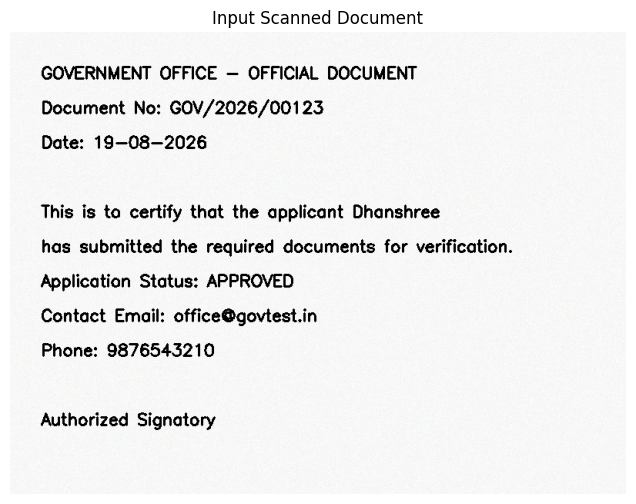

In [ ]:
# Cell 2: Get input scanned document — sample or upload
import os

use_sample = True  # False karke apna scanned doc upload kar sakte ho

def make_synthetic_doc():
    # Synthetic "scanned document" with printed text + some noise/skew for realistic testing
    canvas = np.full((600, 800, 3), 255, dtype=np.uint8)
    lines = [
        "GOVERNMENT OFFICE - OFFICIAL DOCUMENT",
        "Document No: GOV/2026/00123",
        "Date: 19-08-2026",
        "",
        "This is to certify that the applicant Dhanshree",
        "has submitted the required documents for verification.",
        "Application Status: APPROVED",
        "Contact Email: office@govtest.in",
        "Phone: 9876543210",
        "",
        "Authorized Signatory",
    ]
    y = 60
    for line in lines:
        cv2.putText(canvas, line, (40, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)
        y += 45
    # add slight noise to simulate scan artifacts
    noise = np.random.randint(0, 15, canvas.shape, dtype=np.uint8)
    canvas = cv2.subtract(canvas, noise)
    cv2.imwrite("scan.jpg", canvas)

if use_sample:
    make_synthetic_doc()
else:
    uploaded = files.upload()
    input_path = list(uploaded.keys())[0]
    os.rename(input_path, "scan.jpg")

img = cv2.imread("scan.jpg")
assert img is not None, "scan.jpg failed to load."
print("Image shape:", img.shape)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input Scanned Document")
plt.axis('off')
plt.show()

Detected skew angle: -0.00 degrees


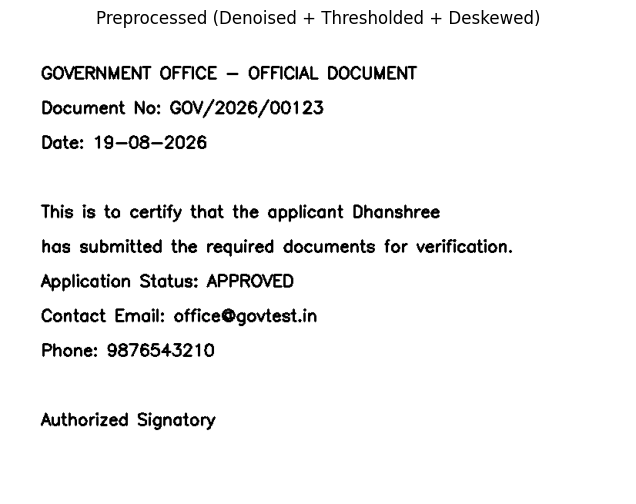

In [ ]:
# Cell 3: Preprocessing pipeline — grayscale, denoise, threshold, deskew
def preprocess_for_ocr(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.fastNlMeansDenoising(gray, h=15)
    thresh = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 31, 15)

    # Deskew using minAreaRect on text pixels
    coords = np.column_stack(np.where(thresh < 255))
    angle = 0.0
    if len(coords) > 0:
        rect_angle = cv2.minAreaRect(coords)[-1]
        angle = -(90 + rect_angle) if rect_angle < -45 else -rect_angle
        if abs(angle) > 0.5:
            (h, w) = thresh.shape
            M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
            thresh = cv2.warpAffine(thresh, M, (w, h), flags=cv2.INTER_CUBIC,
                                     borderMode=cv2.BORDER_REPLICATE)
    return thresh, angle

processed, skew_angle = preprocess_for_ocr(img)
print(f"Detected skew angle: {skew_angle:.2f} degrees")

plt.figure(figsize=(8,6))
plt.imshow(processed, cmap='gray')
plt.title("Preprocessed (Denoised + Thresholded + Deskewed)")
plt.axis('off')
plt.show()

In [ ]:
# Cell 4: Run Tesseract OCR on raw image vs preprocessed image, compare
def run_ocr(image, config='--oem 3 --psm 6'):
    start = time.time()
    text = pytesseract.image_to_string(image, config=config)
    infer_time = time.time() - start
    data = pytesseract.image_to_data(image, config=config, output_type=pytesseract.Output.DICT)
    confidences = [int(c) for c in data['conf'] if c != '-1']
    avg_conf = sum(confidences)/len(confidences) if confidences else 0
    return text.strip(), avg_conf, infer_time

gray_raw = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
raw_text, raw_conf, raw_time = run_ocr(gray_raw)
proc_text, proc_conf, proc_time = run_ocr(processed)

print("="*60)
print("RAW IMAGE OCR OUTPUT:")
print("-"*60)
print(raw_text)
print(f"\nAvg Confidence: {raw_conf:.2f}% | Time: {raw_time*1000:.2f} ms")
print("="*60)
print("PREPROCESSED IMAGE OCR OUTPUT:")
print("-"*60)
print(proc_text)
print(f"\nAvg Confidence: {proc_conf:.2f}% | Time: {proc_time*1000:.2f} ms")
print("="*60)

RAW IMAGE OCR OUTPUT:
------------------------------------------------------------
GOVERNMENT OFFICE — OFFICIAL DOCUMENT

Document No: GOV/2026/00123

Date: 19-08-2026

This is to certify that the applicant Dhanshree

has submitted the required documents for verification.
Application Status: APPROVED

Contact Email: office@govtest.in

Phone: 9876543210

Authorized Signatory

Avg Confidence: 60.59% | Time: 1544.06 ms
PREPROCESSED IMAGE OCR OUTPUT:
------------------------------------------------------------
GOVERNMENT OFFICE — OFFICIAL DOCUMENT

Document No: GOV/2026/00123

Date: 19-08-2026

This is to certify that the applicant Dhanshree

has submitted the required documents for verification.
Application Status: APPROVED

Contact Email: office@govtest.in

Phone: 9876543210

Authorized Signatory

Avg Confidence: 60.59% | Time: 719.35 ms


In [ ]:
# Cell 5: Validate extracted text — check for expected fields/patterns (govt doc use case)
def validate_extracted_text(text):
    results = {}

    doc_no = re.search(r'Document No[:\s]*([A-Z0-9/]+)', text, re.IGNORECASE)
    results['Document Number'] = doc_no.group(1) if doc_no else "NOT FOUND"

    date_match = re.search(r'\b(\d{2}-\d{2}-\d{4})\b', text)
    results['Date'] = date_match.group(1) if date_match else "NOT FOUND"

    email_match = re.search(r'[\w\.-]+@[\w\.-]+\.\w+', text)
    results['Email'] = email_match.group(0) if email_match else "NOT FOUND"

    phone_match = re.search(r'\b\d{10}\b', text)
    results['Phone'] = phone_match.group(0) if phone_match else "NOT FOUND"

    status_match = re.search(r'Status[:\s]*([A-Z]+)', text, re.IGNORECASE)
    results['Status'] = status_match.group(1) if status_match else "NOT FOUND"

    return results

validation = validate_extracted_text(proc_text)

print("VALIDATION REPORT")
print("="*45)
for field, value in validation.items():
    status = "✓ VALID" if value != "NOT FOUND" else "✗ MISSING"
    print(f"{field:<20}: {value:<20} [{status}]")
print("="*45)

valid_count = sum(1 for v in validation.values() if v != "NOT FOUND")
print(f"\nValidation Score: {valid_count}/{len(validation)} fields extracted successfully")

VALIDATION REPORT
Document Number     : GOV/2026/00123       [✓ VALID]
Date                : 19-08-2026           [✓ VALID]
Email               : office@govtest.in    [✓ VALID]
Phone               : 9876543210           [✓ VALID]
Status              : APPROVED             [✓ VALID]

Validation Score: 5/5 fields extracted successfully


In [ ]:
# Cell 6: Performance comparison — raw vs preprocessed
print("="*60)
print(f"{'Metric':<25}{'Raw Image':<20}{'Preprocessed'}")
print("="*60)
print(f"{'Avg Confidence (%)':<25}{raw_conf:<20.2f}{proc_conf:.2f}")
print(f"{'OCR Time (ms)':<25}{raw_time*1000:<20.2f}{proc_time*1000:.2f}")
print(f"{'Chars Extracted':<25}{len(raw_text):<20}{len(proc_text)}")
print("="*60)
print(f"\nPreprocessing improved confidence by {proc_conf - raw_conf:.2f} percentage points.")

Metric                   Raw Image           Preprocessed
Avg Confidence (%)       60.59               60.59
OCR Time (ms)            1544.06             719.35
Chars Extracted          293                 293

Preprocessing improved confidence by 0.00 percentage points.
